# Project Overview: Precision Irrigation Prediction
> **Objective:** Predict precision irrigation needs (Low, Medium, High) using environmental, soil, and crop dynamics.


## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e4')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s6e4


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import pickle
import joblib

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

In [4]:
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [5]:
test_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [7]:
train_df.shape

(630000, 21)

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [9]:
test_df.shape

(270000, 20)

In [10]:
train_df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [11]:
test_df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
dtype: int64

## 3. Exploratory Data Analysis

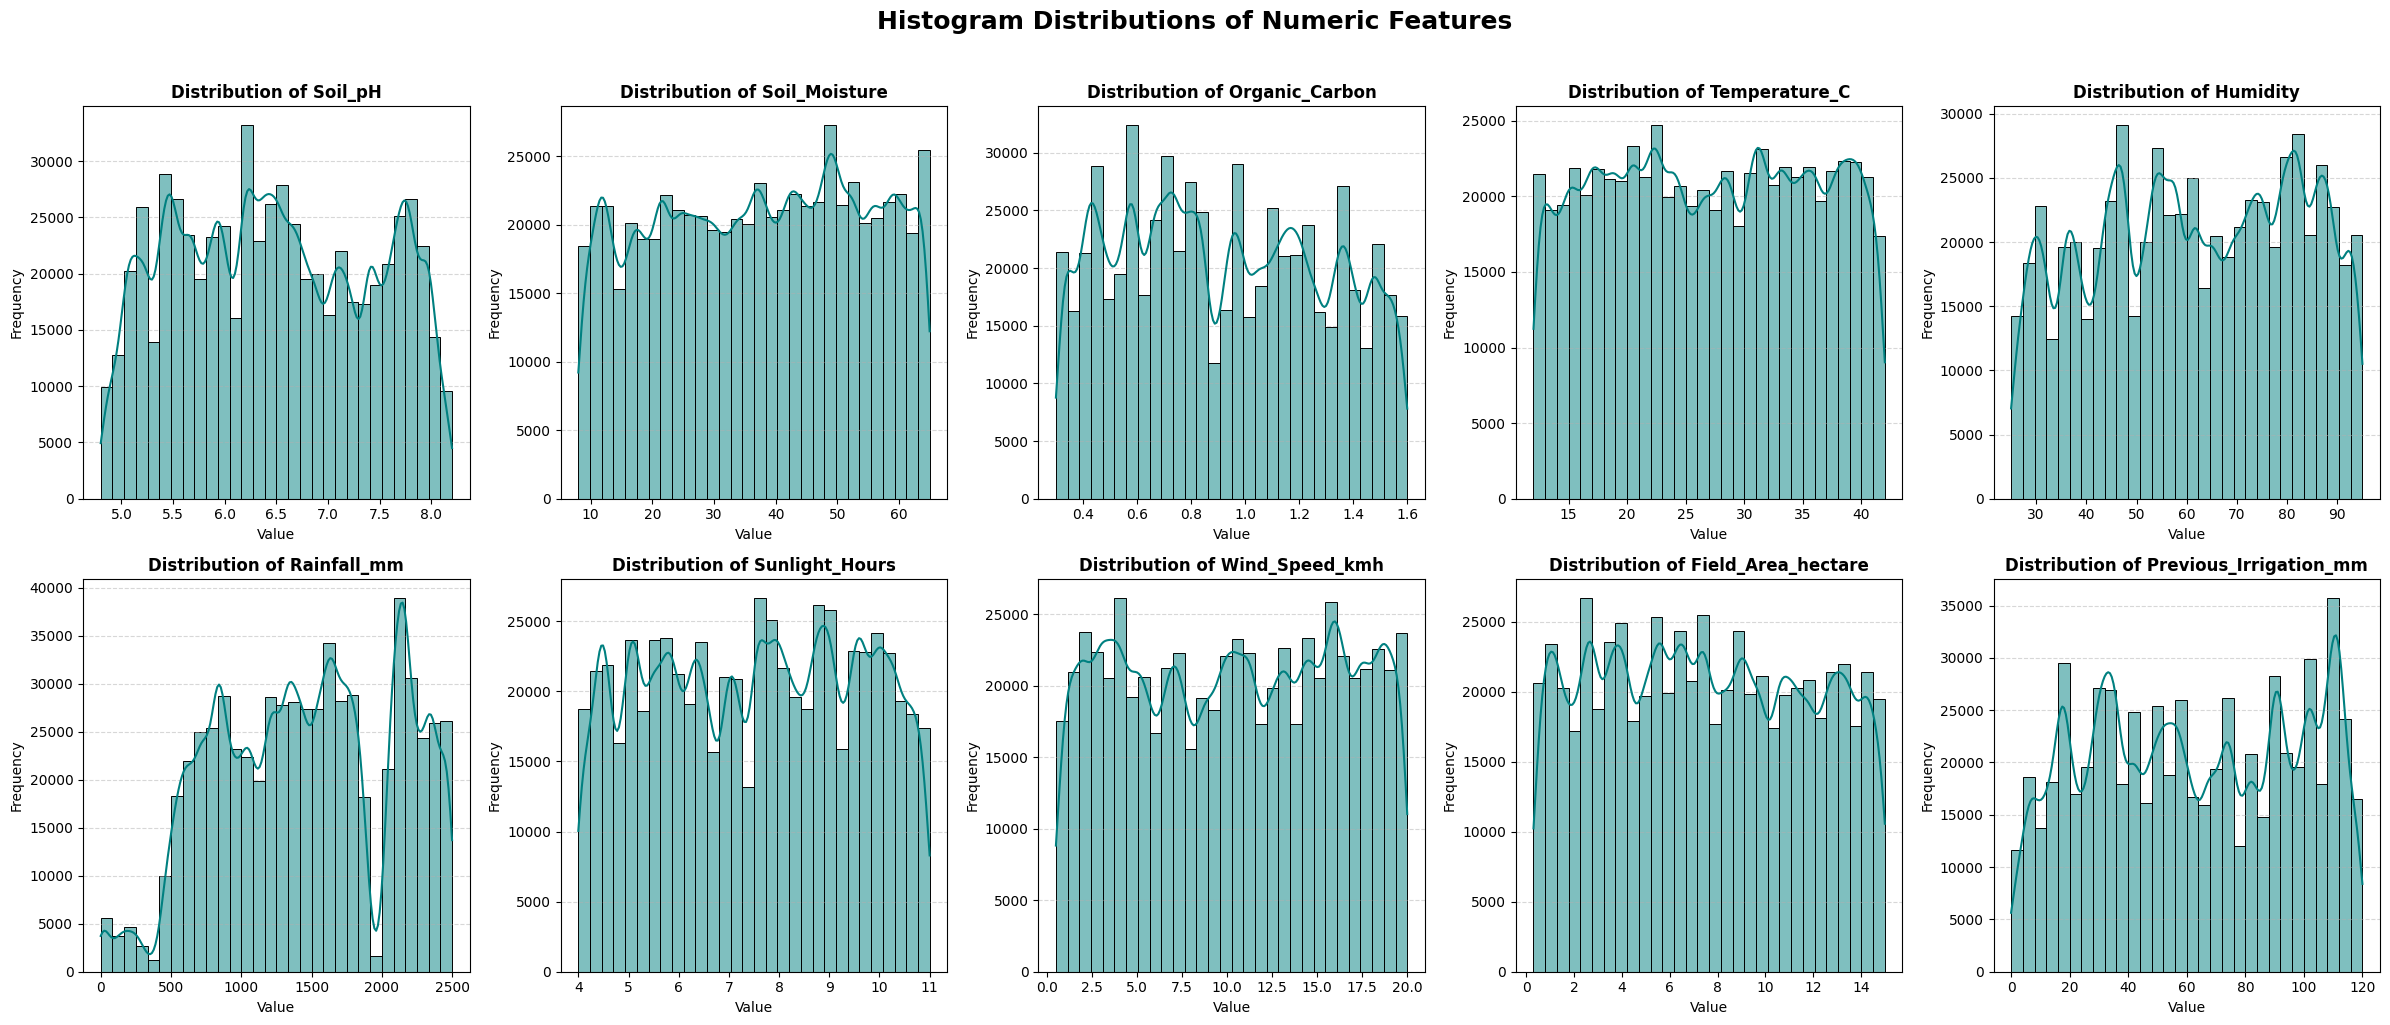

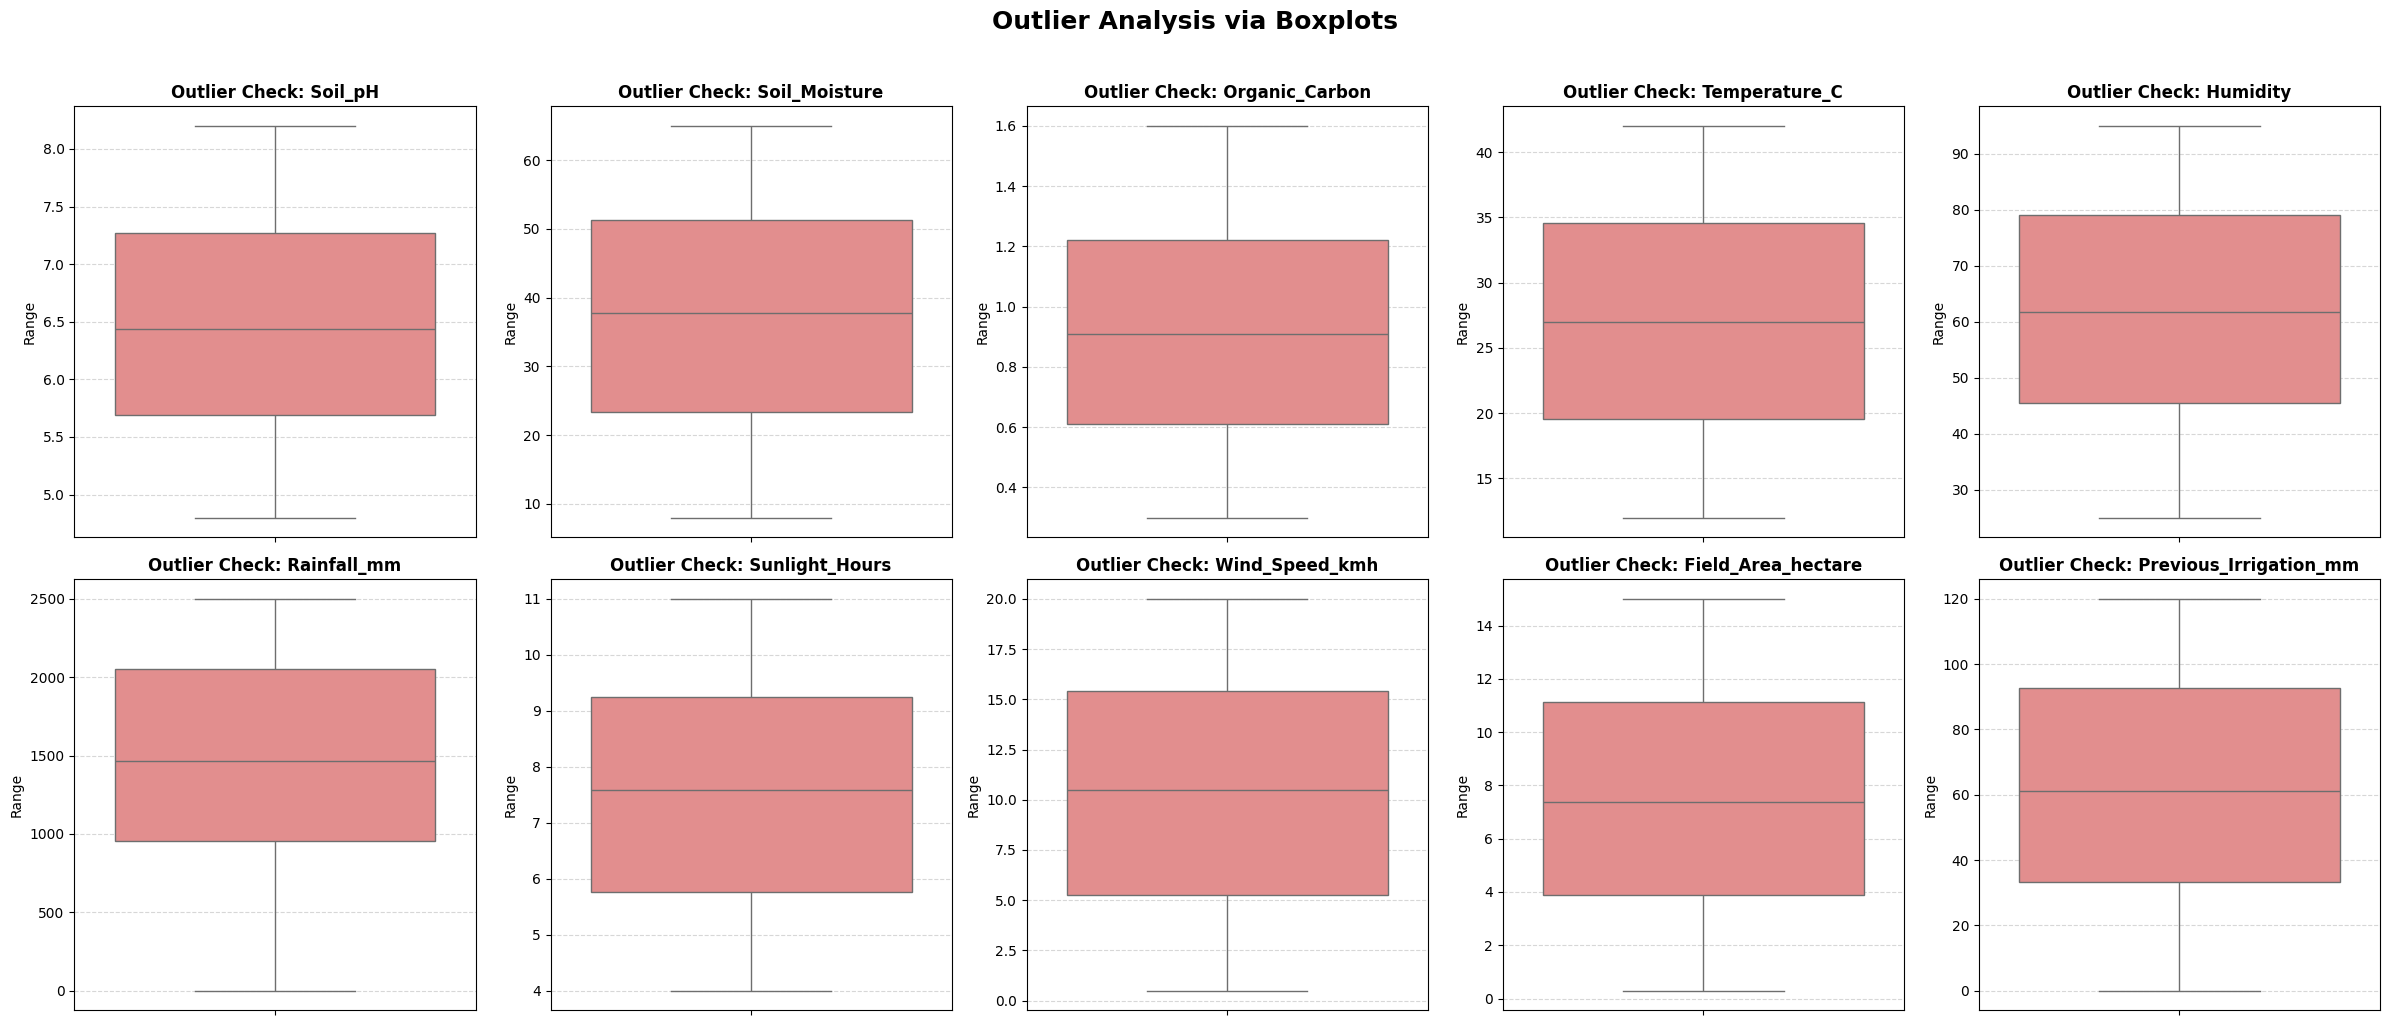

In [12]:
num_features = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Temperature_C', 'Humidity', 
    'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 
    'Previous_Irrigation_mm'
]

# Histogram
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
train_df[num_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.8800,7.38,11.14,15.00
Previous_Irrigation_mm,630000.0,62.318177,34.246939,0.02,33.1400,61.15,92.69,119.99


## 4. Feature Engineering (FE) & Data Preprocessing

In [14]:
train_df['is_train'] = 1
test_df['is_train'] = 0

In [15]:
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [16]:
combined_df

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,is_train
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low,1
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low,1
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low,1
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium,1
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,899995,Sandy,5.63,51.90,0.68,2.58,33.27,72.09,2326.61,7.09,...,Vegetative,Rabi,Rainfed,River,2.93,Yes,43.49,East,NaN,0
899996,899996,Loamy,7.84,45.16,0.85,1.04,27.55,45.16,2322.37,5.15,...,Vegetative,Rabi,Canal,Groundwater,11.23,Yes,92.03,West,NaN,0
899997,899997,Loamy,7.83,11.02,1.56,1.90,23.39,64.87,996.72,10.44,...,Vegetative,Zaid,Sprinkler,Groundwater,2.88,Yes,34.02,East,NaN,0
899998,899998,Silt,7.12,10.18,1.32,2.65,41.09,58.04,1130.71,5.11,...,Harvest,Kharif,Rainfed,River,5.71,Yes,3.92,East,NaN,0


### 4.1. Agricultural Feature Engeneering
* *Agronomic Ratios (EC/Moisture, pH/Carbon Interactions)*
* *Climate & Micro-climate Stress Indices (Dryness, Evapotranspiration Risk)*
* *Hydrological Inputs (Total Water Inflow, Water Intensity per Hectare)*

In [17]:
df_fe = combined_df.copy()

# Electrical Conductivity to Moisture Ratio (Mineral concentration behavior as water depletes)
# Adding a small epsilon (1e-5) to prevent division by zero
df_fe['ec_moisture_ratio'] = df_fe['Electrical_Conductivity'] / (df_fe['Soil_Moisture'] + 1e-5)

In [18]:
# Acid-Base and Organic Carbon Interaction (Signal for soil structural water retention capacity)
df_fe['ph_carbon_interaction'] = df_fe['Soil_pH'] * df_fe['Organic_Carbon']

In [19]:
# Dryness Index (High temperature combined with low humidity accelerates dryness)
df_fe['dryness_index'] = df_fe['Temperature_C'] / (df_fe['Humidity'] + 1e-5)

In [20]:
# Evapotranspiration Risk (Combined effect of wind, sunlight, and heat on evaporation)
df_fe['evapotranspiration_risk'] = df_fe['Temperature_C'] * df_fe['Wind_Speed_kmh'] * df_fe['Sunlight_Hours']

In [21]:
# Thermal Load (Total intensity of sunlight and temperature exposure)
df_fe['sunlight_thermal_load'] = df_fe['Sunlight_Hours'] * df_fe['Temperature_C']

In [22]:
# Total Water Inflow (Natural rainfall + Previous human irrigation)
df_fe['total_water_inflow_mm'] = df_fe['Rainfall_mm'] + df_fe['Previous_Irrigation_mm']

In [23]:
# Water Intensity Per Hektar (Distribution and scale effect of water over the field area)
df_fe['water_intensity_per_hectar'] = df_fe['total_water_inflow_mm'] / (df_fe['Field_Area_hectare'] + 1e-5)

In [24]:
# Simulating the microclimate effect of mulching on topsoil temperature
df_fe['mulching_numeric'] = np.where(df_fe['Mulching_Used'] == 'Yes', 1, 0)

# Calculate the temperature exposure based on mulching status
# If mulching is NOT used (0), temperature risk is fully active.
df_fe['mulch_temp_exposure'] = df_fe['Temperature_C'] * (1 - df_fe['mulching_numeric'])

In [25]:
df_fe.shape

(900000, 31)

In [26]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          900000 non-null  int64  
 1   Soil_Type                   900000 non-null  object 
 2   Soil_pH                     900000 non-null  float64
 3   Soil_Moisture               900000 non-null  float64
 4   Organic_Carbon              900000 non-null  float64
 5   Electrical_Conductivity     900000 non-null  float64
 6   Temperature_C               900000 non-null  float64
 7   Humidity                    900000 non-null  float64
 8   Rainfall_mm                 900000 non-null  float64
 9   Sunlight_Hours              900000 non-null  float64
 10  Wind_Speed_kmh              900000 non-null  float64
 11  Crop_Type                   900000 non-null  object 
 12  Crop_Growth_Stage           900000 non-null  object 
 13  Season        

### 4.2. Categorical Encoding

In [27]:
df_encoded = df_fe.copy()

low_cardinality_cols = ['Season', 'Irrigation_Type', 'Water_Source']

df_encoded = pd.get_dummies(
    df_encoded, 
    columns=low_cardinality_cols, 
    drop_first=True, 
    dtype=int # Keeps the output as 1 and 0 instead of True/False
)

In [28]:
structural_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Region']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded[structural_cols] = encoder.fit_transform(df_encoded[structural_cols].astype(str))

In [29]:
df_encoded = df_encoded.drop(columns=['Mulching_Used'], errors='ignore')

In [30]:
df_encoded

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,mulching_numeric,mulch_temp_exposure,Season_Rabi,Season_Zaid,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River
0,0,1.0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,0,15.01,0,1,1,0,0,1,0,0
1,1,0.0,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,1,0.00,0,0,0,1,0,0,0,1
2,2,0.0,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,1,0.00,0,0,0,0,1,0,1,0
3,3,2.0,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,1,0.00,0,0,0,0,0,0,0,1
4,4,0.0,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,0,20.22,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,899995,2.0,5.63,51.90,0.68,2.58,33.27,72.09,2326.61,7.09,...,1,0.00,1,0,0,1,0,0,0,1
899996,899996,1.0,7.84,45.16,0.85,1.04,27.55,45.16,2322.37,5.15,...,1,0.00,1,0,0,0,0,0,0,0
899997,899997,1.0,7.83,11.02,1.56,1.90,23.39,64.87,996.72,10.44,...,1,0.00,0,1,0,0,1,0,0,0
899998,899998,3.0,7.12,10.18,1.32,2.65,41.09,58.04,1130.71,5.11,...,1,0.00,0,0,0,1,0,0,0,1


### 4.3. Feature Alignment and Train-Test Split Verification

In [31]:
train_final = df_encoded[df_encoded['is_train'] == 1].drop(columns=['is_train'])
test_final = df_encoded[df_encoded['is_train'] == 0].drop(columns=['is_train'])

In [32]:
x_train = train_final.drop(columns=['id', 'Irrigation_Need'])
y_train = train_final['Irrigation_Need']

In [33]:
x_test = test_final.drop(columns=['id', 'Irrigation_Need'])
test_ids = test_final['id']

In [34]:
target_map = {'Low': 0, 'Medium': 1, 'High': 2}

y_train_encoded = y_train.map(target_map)

In [35]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 270000 entries, 630000 to 899999
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Soil_Type                   270000 non-null  float64
 1   Soil_pH                     270000 non-null  float64
 2   Soil_Moisture               270000 non-null  float64
 3   Organic_Carbon              270000 non-null  float64
 4   Electrical_Conductivity     270000 non-null  float64
 5   Temperature_C               270000 non-null  float64
 6   Humidity                    270000 non-null  float64
 7   Rainfall_mm                 270000 non-null  float64
 8   Sunlight_Hours              270000 non-null  float64
 9   Wind_Speed_kmh              270000 non-null  float64
 10  Crop_Type                   270000 non-null  float64
 11  Crop_Growth_Stage           270000 non-null  float64
 12  Field_Area_hectare          270000 non-null  float64
 13  Previous_Irrig

## 5. Model Training, Optimization & Deployment Strategy

In [39]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight


b = BernoulliNB()
l = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
d = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced', n_jobs=-1, random_state=42)
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
kn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
ab = AdaBoostClassifier(random_state=42)
mn = MultinomialNB()

def algo_test(x, y):
    models = [b, l, d, r, gb, kn, ab, mn]
    model_names = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
                   "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
                   "AdaBoostClassifier", "MultinomialNB"]

    
    x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(x, y, test_size=0.20, random_state=42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    successful_models = []
    successful_names = []

        
    computed_weights = compute_sample_weight(class_weight='balanced', y=y_train_split)
    
    for model, name in zip(models, model_names):
        print(f"--> Training {name}...")
        try:
            try:
                
                model_fitted = model.fit(x_train_split, y_train_split, sample_weight=computed_weights)
            except TypeError:
                model_fitted = model.fit(x_train_split, y_train_split)
                
            prediction = model_fitted.predict(x_val_split.values)
            
            accuracy.append(accuracy_score(y_val_split, prediction))
            precision.append(precision_score(y_val_split, prediction, average="micro"))
            recall.append(recall_score(y_val_split, prediction, average="micro"))
            f1.append(f1_score(y_val_split, prediction, average="micro"))
            successful_models.append(model_fitted)
            successful_names.append(name)
            
            print(f"Confusion Matrix ({name}):")
            print(confusion_matrix(y_val_split, prediction))
            print("-" * 40)
            
        except Exception as e:
            print(f" Error training {name}: {e}")
            print("-" * 40)
            continue

    
    metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=successful_names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"] = successful_models

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("=" * 50)
    print("Most Successful Model: ", metrics.iloc[0].name)
    print("=" * 50)
    
    best_model = metrics.iloc[0]["Model"]
    
    final_prediction = best_model.predict(x_val_split.values)
    
    print("\nBest Model Confusion Matrix:")
    print(confusion_matrix(y_val_split, final_prediction))
    print("\nBest Model Classification Report:")
    print(classification_report(y_val_split, final_prediction))
    print("\nOverall Model Leaderboard Rankings:")
    
    report_df = metrics.drop("Model", axis=1)
    return report_df, metrics

In [40]:
model_perf_report, trained_metrics_df = algo_test(x_train, y_train_encoded)

--> Training BernoulliNB...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


Confusion Matrix (BernoulliNB):
[[43450  3033 27254]
 [13717  3324 30973]
 [  430   121  3698]]
----------------------------------------
--> Training LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Confusion Matrix (LogisticRegression):
[[47773 16956  9008]
 [ 7081 14478 26455]
 [    5    52  4192]]
----------------------------------------
--> Training DecisionTreeClassifier...


...

Confusion Matrix (KNeighborsClassifier):
[[58350 15336    51]
 [24858 22556   600]
 [  850  2087  1312]]
----------------------------------------
--> Training AdaBoostClassifier...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


Confusion Matrix (AdaBoostClassifier):
[[51475 22262     0]
 [  269 45979  1766]
 [    1   247  4001]]
----------------------------------------
--> Training MultinomialNB...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Confusion Matrix (MultinomialNB):
[[48146 14882 10709]
 [20806 13343 13865]
 [  428   896  2925]]
----------------------------------------
Most Successful Model:  RandomForestClassifier

Best Model Confusion Matrix:
[[73282   455     0]
 [  988 46900   126]
 [    0   540  3709]]

Best Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73737
           1       0.98      0.98      0.98     48014
           2       0.97      0.87      0.92      4249

    accuracy                           0.98    126000
   macro avg       0.98      0.95      0.96    126000
weighted avg       0.98      0.98      0.98    126000


Overall Model Leaderboard Rankings:


In [41]:
model_perf_report

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.983262,0.983262,0.983262,0.983262
GradientBoostingClassifier,0.961659,0.961659,0.961659,0.961659
DecisionTreeClassifier,0.947540,0.947540,0.947540,0.947540
AdaBoostClassifier,0.805198,0.805198,0.805198,0.805198
KNeighborsClassifier,0.652524,0.652524,0.652524,0.652524
LogisticRegression,0.527325,0.527325,0.527325,0.527325
MultinomialNB,0.511222,0.511222,0.511222,0.511222
BernoulliNB,0.400571,0.400571,0.400571,0.400571


In [43]:
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(x_train, y_train, test_size=0.20, random_state=42)

In [44]:
r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced', n_jobs=-1, random_state=42)

In [45]:
r.fit(x_train_split, y_train_split)

RandomForestClassifier(class_weight='balanced', max_samples=0.2, n_jobs=-1,
                       random_state=42)

In [49]:
y_pred = r.predict(x_val_split.values)
y_probs = r.predict_proba(x_val_split.values)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [50]:
unique_classes = np.unique(y_val_split)
n_classes = len(unique_classes)

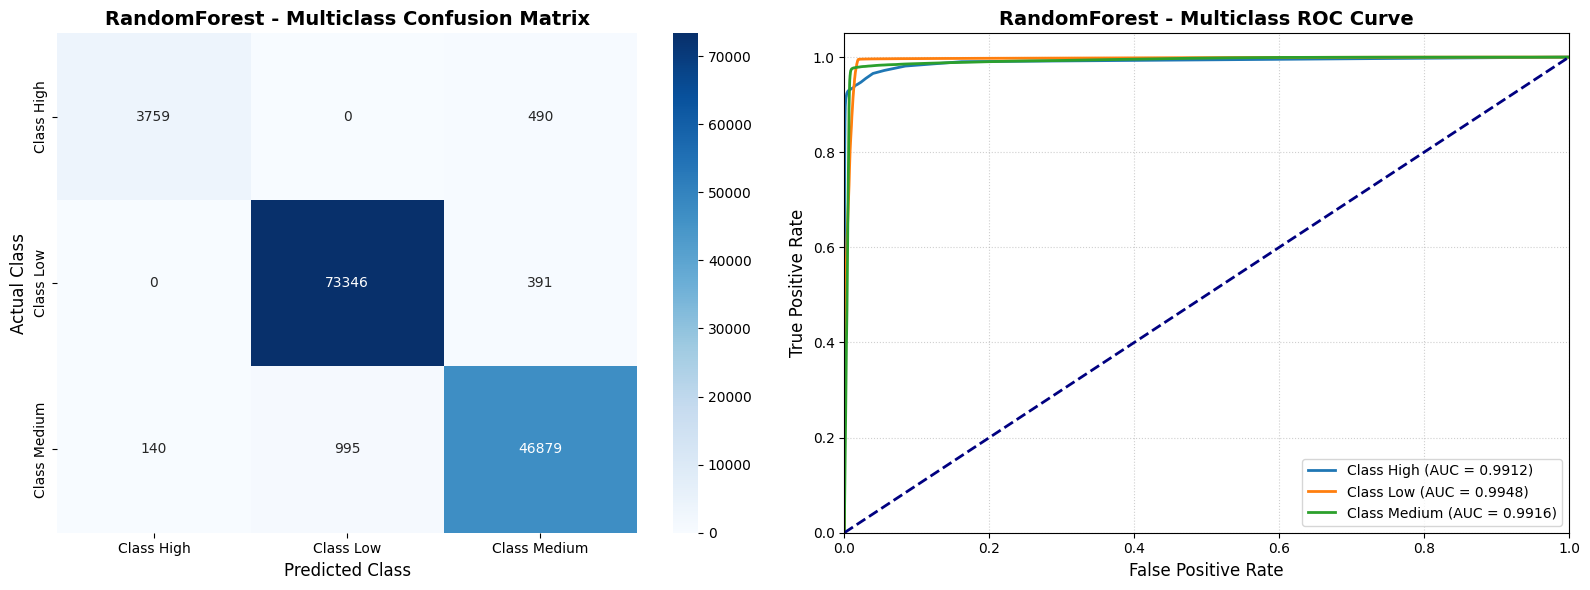

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CM
cm = confusion_matrix(y_val_split, y_pred)

class_labels = [f"Class {c}" for c in unique_classes]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title('RandomForest - Multiclass Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('Actual Class', fontsize=12)


# ROC

y_val_binarized = label_binarize(y_val_split, classes=unique_classes)

# Her bir sınıf için ayrı bir ROC eğrisi çizdiriyoruz
for i in range(n_classes):
    # Eğer veri seti aslında binary ise ama encode problemi varsa hata almamak için kontrol
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_val_split, y_probs[:, 1])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
        break
    else:
        fpr, tpr, _ = roc_curve(y_val_binarized[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, label=f'Class {unique_classes[i]} (AUC = {roc_auc:.4f})')

axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('RandomForest - Multiclass ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [54]:
final_champion_model = RandomForestClassifier(
    n_estimators=100, 
    max_samples=0.2, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)

In [55]:
final_champion_model.fit(x_train.values, y_train_encoded.values)

RandomForestClassifier(class_weight='balanced', max_samples=0.2, n_jobs=-1,
                       random_state=42)

In [56]:
final_test_predictions = final_champion_model.predict(x_test.values)

In [57]:
inverse_target_map = {0: 'Low', 1: 'Medium', 2: 'High'}
final_submission_labels = pd.Series(final_test_predictions).map(inverse_target_map)

In [58]:
submission_df = pd.DataFrame()
submission_df['id'] = test_ids.values
submission_df['Irrigation_Need'] = final_submission_labels.values

submission_file_name = "sample_submission.csv"
submission_df.to_csv(submission_file_name, index=False)

In [59]:
with open('final_champion_model.pkl', 'wb') as f:
    pickle.dump(final_champion_model, f)

In [60]:
joblib.dump(final_champion_model, 'RF_Irrigation.joblib')

['RF_Irrigation.joblib']